# Tutorial 04 - Donchian and Turtle breakout with DeTime volume confirmation

Breakout systems fail when every new high is treated as the same event. This tutorial starts with Donchian/Turtle channels, then adds DeTime trend, cycle, residual and volume gates.

The goal is not to remove breakout logic. The goal is to ask whether a price breakout is supported by structural trend and participation, or whether it is just a noisy cycle high.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from examples.quant_trading.data import load_sample_goog_ohlcv, market_data_manifest, ohlcv_audit_report
from examples.quant_trading.features import build_feature_table, decompose_one_series, walkforward_decompose_ohlcv
from examples.quant_trading.classic_indicators import donchian_channels
from examples.quant_trading.strategy_baselines import make_classic_breakout_weight_grid, run_classical_breakout_baselines
from examples.quant_trading.strategy_detime import make_detime_breakout_weight_grid, run_detime_breakout_baselines, compare_classical_and_detime
from examples.quant_trading.validation import compare_weight_strategies, write_run_audit, write_run_manifest

pd.set_option("display.max_columns", 30)
report_dir = Path("examples/quant_trading/reports")
report_dir.mkdir(parents=True, exist_ok=True)


## 1. Load OHLCV data

Breakout strategies use high and low channels, so this tutorial uses the full OHLCV sample rather than close alone.

In [2]:
ohlcv_single = load_sample_goog_ohlcv(trim_start="2014-01-01")
ticker = ohlcv_single.attrs.get("symbol", "GOOG")
ohlcv = {field: ohlcv_single[[field]].rename(columns={field: ticker}) for field in ["Open", "High", "Low", "Close", "Volume"]}
prices = ohlcv["Close"]
high = ohlcv["High"]
low = ohlcv["Low"]
manifest = market_data_manifest(tickers=[ticker], start=str(prices.index.min().date()), end=str(prices.index.max().date()), interval="1d", source=ohlcv_single.attrs.get("source", "bundled real sample"))
audit = ohlcv_audit_report(ohlcv)
display(audit)

,ticker,first_timestamp,last_timestamp,observations,close_missing_ratio,volume_missing_ratio,zero_volume_ratio,min_close,max_close,median_volume
0,GOOG,2014-01-02,2018-01-02,1008,0.0,0.0,0.0,491.201416,1077.140015,1624450.0


## 2. Classical Donchian/Turtle baselines

The baseline enters on a prior-channel breakout and exits on a shorter-channel break. The channel is shifted by one bar to avoid comparing today's close with a channel that already includes today's high.

In [3]:
classic_breakout_weights = make_classic_breakout_weight_grid(prices, high=high, low=low)
classic_table, classic_results = compare_weight_strategies(prices, classic_breakout_weights, fee_bps=1.0, slippage_bps=2.0)
display(classic_table[["total_return", "cagr", "sharpe", "max_drawdown", "average_turnover"]].round(4))

,total_return,cagr,sharpe,max_drawdown,average_turnover
strategy,,,,,
classic_donchian_20_10,0.0530,0.0130,0.1587,-0.1950,0.0407
classic_turtle_55_20,0.0416,0.0102,0.1406,-0.1248,0.0208
classic_turtle_55_20_long_short,-0.2099,-0.0572,-0.2800,-0.3194,0.0308


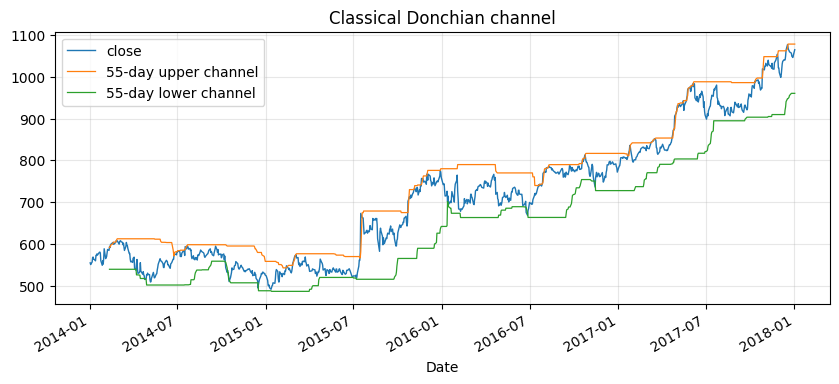

In [4]:
channel = donchian_channels(high, low, window=55, shift=1)
fig, ax = plt.subplots(figsize=(10, 4))
prices[ticker].plot(ax=ax, linewidth=1.0, label="close")
channel.upper[ticker].plot(ax=ax, linewidth=0.9, label="55-day upper channel")
channel.lower[ticker].plot(ax=ax, linewidth=0.9, label="55-day lower channel")
ax.set_title("Classical Donchian channel")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 3. DeTime breakout gates

The DeTime version still needs a price breakout. It then asks four structural questions: is the trend rising, is the cycle not fighting the entry, is the residual not already overextended, and is volume participation present?

In [5]:
features = walkforward_decompose_ohlcv(
    ohlcv,
    method="STL",
    period="auto",
    period_candidates=(63, 126, 252),
    train_window=504,
    step=5,
    z_window=63,
)
feature_tail = build_feature_table(prices, features).tail(120)
display(feature_tail.tail(5).round(4))
feature_tail.to_csv(report_dir / "column_04_feature_table_tail.csv")


,component_stability,cycle,cycle_amplitude,cycle_position,cycle_slope,cycle_turn_up,cycle_z,realized_vol_20,reconstruction_error,residual,residual_abs_z,residual_vol,residual_z,return_1d,season,...,volume_cycle_turn_up,volume_cycle_z,volume_participation,volume_reconstruction_error,volume_residual,volume_residual_abs_z,volume_residual_vol,volume_residual_z,volume_selected_period,volume_shock,volume_trend,volume_trend_acceleration,volume_trend_gap,volume_trend_slope,volume_trend_strength
,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,...,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017-12-26,0.9853,0.0456,0.0438,1.0414,-0.0051,0.0,0.6138,0.1515,0.0,0.0004,0.1109,0.0149,0.1109,-0.0032,0.0456,...,0.0,-0.5708,2.0,0.0,-0.2911,2.3259,0.1243,-2.3259,126.0,2.3259,14.0559,-0.0,-0.514,-0.0011,-0.0031
2017-12-27,0.9853,0.0456,0.0438,1.0414,-0.0051,0.0,0.6138,0.1518,0.0,0.0004,0.1109,0.0149,0.1109,-0.0070,0.0456,...,0.0,-0.5708,2.0,0.0,-0.2911,2.3259,0.1243,-2.3259,126.0,2.3259,14.0559,-0.0,-0.514,-0.0011,-0.0031
2017-12-28,0.9853,0.0456,0.0438,1.0414,-0.0051,0.0,0.6138,0.1226,0.0,0.0004,0.1109,0.0149,0.1109,-0.0012,0.0456,...,0.0,-0.5708,2.0,0.0,-0.2911,2.3259,0.1243,-2.3259,126.0,2.3259,14.0559,-0.0,-0.514,-0.0011,-0.0031
2017-12-29,0.9853,0.0456,0.0438,1.0414,-0.0051,0.0,0.6138,0.1229,0.0,0.0004,0.1109,0.0149,0.1109,-0.0017,0.0456,...,0.0,-0.5708,2.0,0.0,-0.2911,2.3259,0.1243,-2.3259,126.0,2.3259,14.0559,-0.0,-0.514,-0.0011,-0.0031
2018-01-02,0.9853,0.0456,0.0438,1.0414,-0.0051,0.0,0.6138,0.1270,0.0,0.0004,0.1109,0.0149,0.1109,0.0178,0.0456,...,0.0,-0.5708,2.0,0.0,-0.2911,2.3259,0.1243,-2.3259,126.0,2.3259,14.0559,-0.0,-0.514,-0.0011,-0.0031


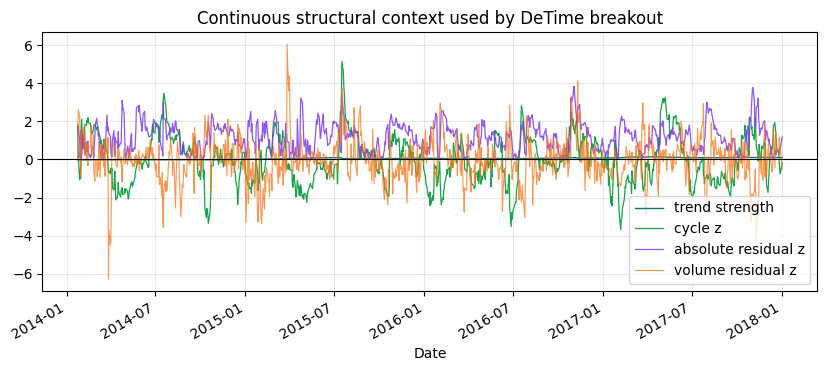

In [6]:
diagnostic = decompose_one_series(
    prices[ticker],
    method="STL",
    period="auto",
    period_candidates=(63, 126, 252),
    z_window=63,
    transform="log",
)
volume_diagnostic = decompose_one_series(
    ohlcv["Volume"][ticker],
    method="STL",
    period=int(diagnostic.attrs.get("period", 126)),
    z_window=63,
    transform="log1p",
)

fig, ax = plt.subplots(figsize=(10, 3.8))
diagnostic["trend_strength"].plot(ax=ax, linewidth=1.0, color="#0f766e", label="trend strength")
diagnostic["cycle_z"].plot(ax=ax, linewidth=0.9, color="#16a34a", label="cycle z")
diagnostic["residual_abs_z"].plot(ax=ax, linewidth=0.9, color="#7c3aed", alpha=0.85, label="absolute residual z")
volume_diagnostic["residual_z"].plot(ax=ax, linewidth=0.8, color="#f97316", alpha=0.75, label="volume residual z")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Continuous structural context used by DeTime breakout")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 4. DeTime breakout results

The comparison is a simple research backtest showing how the signal is constructed and audited.

In [7]:
detime_breakout_weights = make_detime_breakout_weight_grid(prices, features, high=high, low=low)
detime_table, detime_results = compare_weight_strategies(prices, detime_breakout_weights, fee_bps=1.0, slippage_bps=2.0)
display(detime_table[["total_return", "cagr", "sharpe", "max_drawdown", "average_turnover"]].round(4))

,total_return,cagr,sharpe,max_drawdown,average_turnover
strategy,,,,,
detime_donchian_55_20_volume,0.0863,0.0209,0.4521,-0.0697,0.0069
detime_turtle_55_20,0.0863,0.0209,0.4521,-0.0697,0.0069
detime_donchian_20_10_volume,-0.1479,-0.0392,-0.5046,-0.1946,0.0248


In [8]:
classical = run_classical_breakout_baselines(prices, high=high, low=low, fee_bps=1.0, slippage_bps=2.0)
detime = run_detime_breakout_baselines(prices, features, high=high, low=low, fee_bps=1.0, slippage_bps=2.0)
comparison = compare_classical_and_detime(classical, detime)
display(comparison[["strategy_group", "cagr", "sharpe", "max_drawdown", "average_turnover", "hit_rate"]].round(4))
comparison.to_csv(report_dir / "column_04_strategy_comparison.csv")
write_run_audit(report_dir, data_manifest=manifest, audit=audit, strategy_stats=comparison, prefix="column_04")
manifest_path = write_run_manifest(
    report_dir / "column_04_run_manifest.json",
    command="notebook:04_turtle_donchian_breakout_volume_confirmation",
    dataset="bundled_real_GOOG",
    strategies=list(comparison.index),
    result_file=str(report_dir / "column_04_strategy_comparison.csv"),
)
manifest_path.as_posix()

,strategy_group,cagr,sharpe,max_drawdown,average_turnover,hit_rate
strategy,,,,,,
detime_donchian_55_20_volume,detime,0.0209,0.4521,-0.0697,0.0069,0.0526
detime_turtle_55_20,detime,0.0209,0.4521,-0.0697,0.0069,0.0526
classic_donchian_20_10,classical,0.0130,0.1587,-0.1950,0.0407,0.2351
classic_turtle_55_20,classical,0.0102,0.1406,-0.1248,0.0208,0.1925
classic_turtle_55_20_long_short,classical,-0.0572,-0.2800,-0.3194,0.0308,0.2569
detime_donchian_20_10_volume,detime,-0.0392,-0.5046,-0.1946,0.0248,0.0734


'examples/quant_trading/reports/column_04_run_manifest.json'

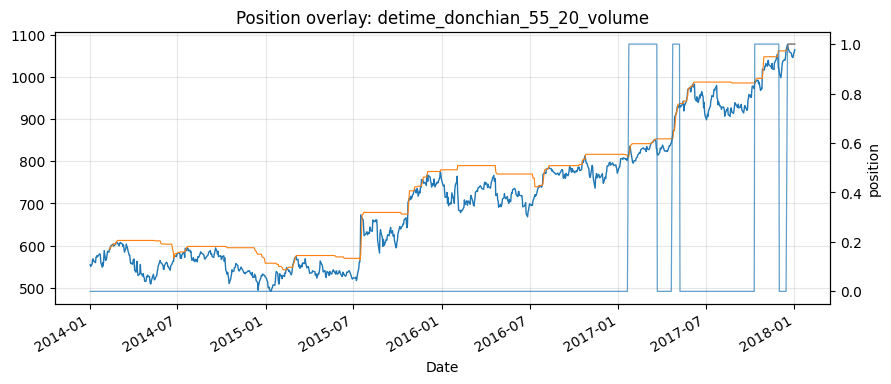

In [9]:
chosen = "detime_donchian_55_20_volume"
fig, ax1 = plt.subplots(figsize=(10, 4))
prices[ticker].plot(ax=ax1, linewidth=1.0, label="close")
channel.upper[ticker].plot(ax=ax1, linewidth=0.8, label="55-day upper")
ax1.set_title(f"Position overlay: {chosen}")
ax2 = ax1.twinx()
detime_breakout_weights[chosen][ticker].plot(ax=ax2, linewidth=0.9, alpha=0.7, label="position")
ax2.set_ylabel("position")
ax1.grid(True, alpha=0.3)
plt.show()

## Takeaway

A channel breakout is a price event. A tradable breakout also needs context. DeTime supplies that context explicitly: trend estimates direction, cycle estimates whether the entry is fighting a local oscillation, residual caps overextension, and decomposed volume distinguishes participation from ordinary noise.